In [65]:
import sys
sys.path.insert(0,'../scripts')
from pathlib import Path
from pycap_for_PESTPP_MOU import postprocess_MOU, prep_for_viz
from pathlib import Path

import yaml
import matplotlib.pyplot as plt
import pandas as pd

In [71]:
scenario_path = Path(r'..\pycap_runs\pycap_pest')

configurations = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_Tmin10per_0.0_1.0_0.01', 'depletion_q_Tplus10per_0.0_1.0_0.01', 'depletion_q_Tmin1mag_0.0_1.0_0.01', 'depletion_q_Tplus1mag_0.0_1.0_0.01', 'depletion_q_Smin1mag_0.0_1.0_0.01', 'depletion_q_Smin10per_0.0_1.0_0.01', 'depletion_q_Splus10per_0.0_1.0_0.01']
baseline_configs = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_baselinev2_0.0_1.0_0.01', 'depletion_q_baselinev3_0.0_1.0_0.01', 'depletion_q_baselinev4_0.0_1.0_0.01', 'depletion_q_baselinev5_0.0_1.0_0.01']

In [67]:
# Get the pareto_final_df and dv_df for the scenario configurations
scen_df_list = []
scen_dv_list = []
for run_name in configurations:
    run_path = scenario_path / f"run_{run_name}"
    pareto_df = postprocess_MOU(run_name, run_path)
    pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=False)
    pareto_df_final.insert(2, "Streamflow (cfs)", 8.6 - pareto_df_final["Depletion (cfs)"])
    scen_df_list.append(pareto_df_final)
    scen_dv_list.append(dv_df)

# Get the pareto_df_final and dv_df for the baseline configurations
baseline_df_list = []
baseline_dv_list = []
for run_name in baseline_configs:
    run_path = scenario_path / f"run_{run_name}"
    pareto_df = postprocess_MOU(run_name, run_path)
    pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=False)
    pareto_df_final.insert(2, "Streamflow (cfs)", 8.6 - pareto_df_final["Depletion (cfs)"])
    baseline_df_list.append(pareto_df_final)
    baseline_dv_list.append(dv_df)

In [72]:
# Plot styling
# colors = ["red", "blue", "green", "orange", "purple", "cyan", "magenta", "yellow"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]
markers = ["o", "s", "D", "^", "v", "<", ">", "P"]

base_name_list = [name.split("_")[2] for name in baseline_configs]
scen_name_list = [name.split("_")[2] for name in configurations]

zoom = False

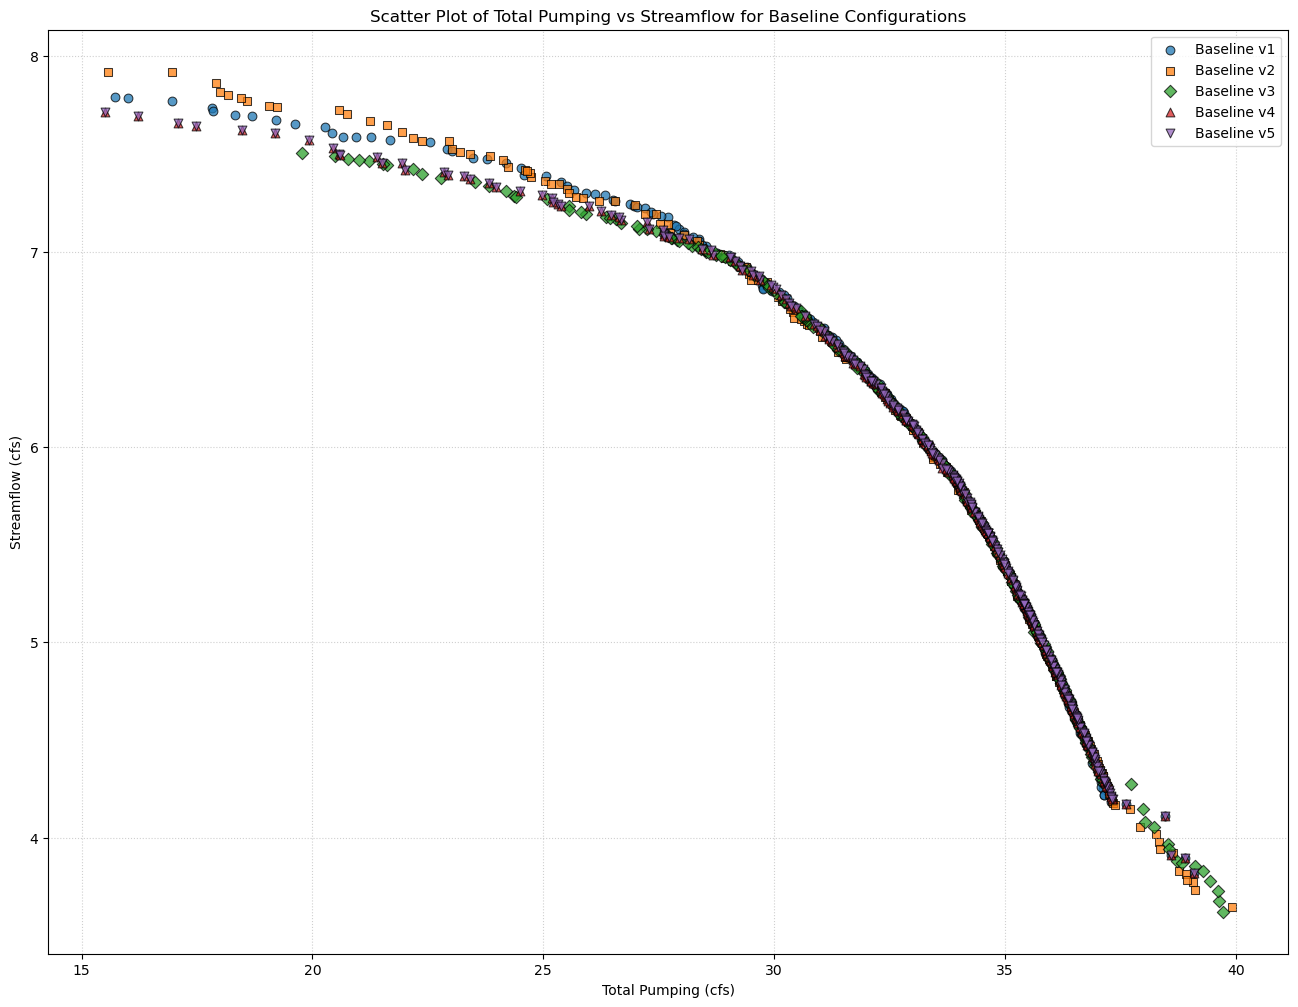

In [73]:
# Create a scatter plot of Total Pumping vs Streamflow for the baseline configurations
plt.figure(figsize=(16, 12))
for i, baseline_df in enumerate(baseline_df_list):
    plt.scatter(baseline_df["Total Pumping (cfs)"], baseline_df["Streamflow (cfs)"], marker=markers[i], s=80 if zoom else 40, color=colors[i], edgecolors="black", linewidths=0.75, alpha=0.75, label=f'Baseline v{i + 1}')
plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.title("Scatter Plot of Total Pumping vs Streamflow for Baseline Configurations")
if zoom:
    plt.xlim(25, 34)
    plt.ylim(6, 7.5)
    # plt.xlim(30, 35)
    # plt.ylim(6, 7)
    # plt.xlim(20, 25)
    # plt.ylim(7, 8)
plt.grid(linestyle=":", alpha=0.6)
plt.legend()
plt.show()

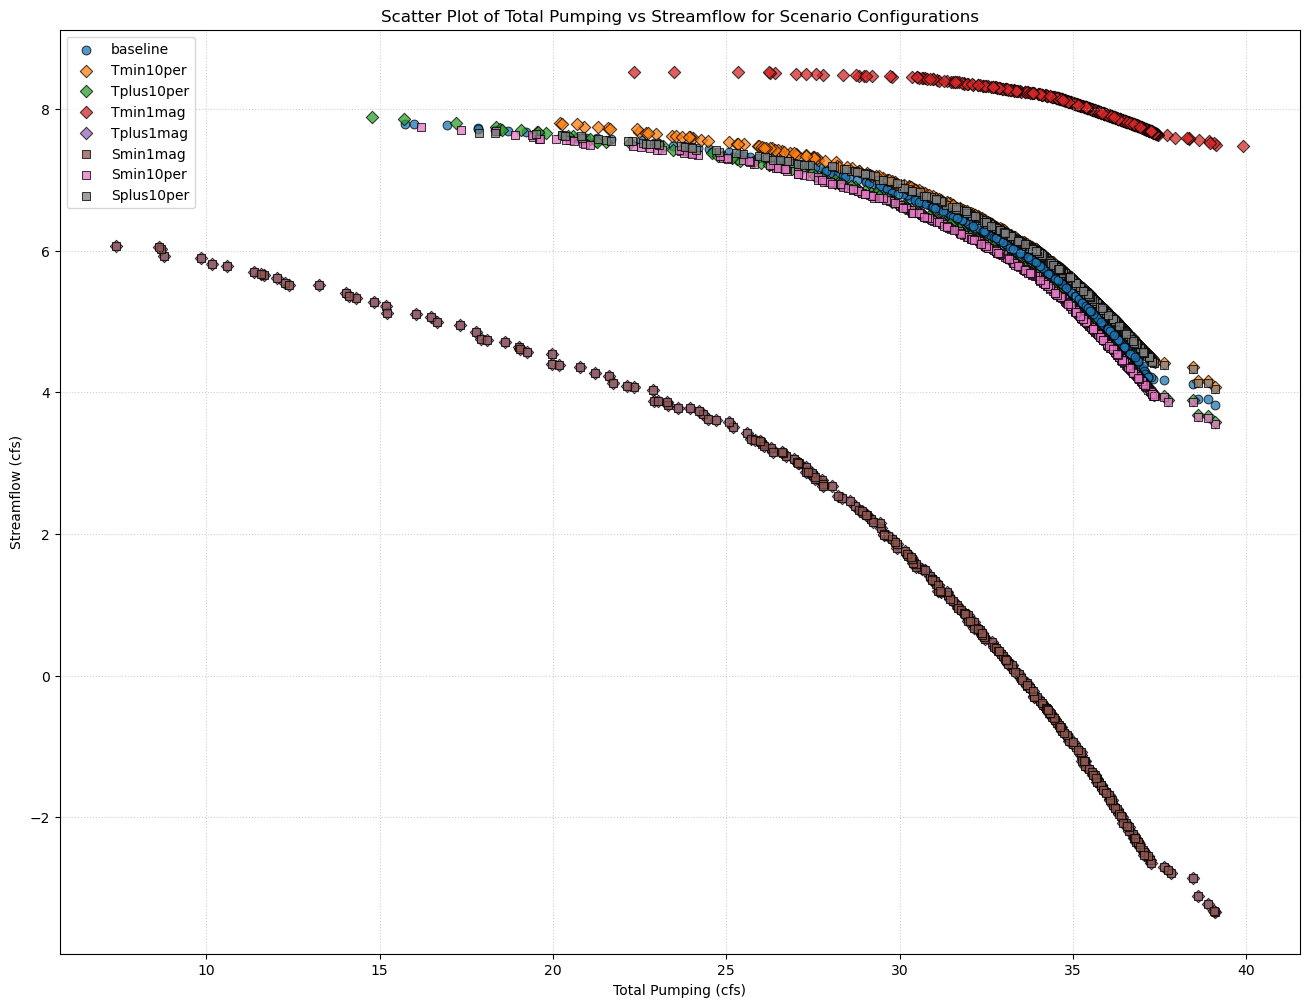

In [74]:
# Create a scatter plot of Total Pumping vs Streamflow for the scenario configurations
plt.figure(figsize=(16, 12))
for i, scen_df in enumerate(scen_df_list):
    m = 0 if "baseline" in scen_name_list[i] else 1 if 's'.upper() in scen_name_list[i] else 2
    plt.scatter(scen_df["Total Pumping (cfs)"], scen_df["Streamflow (cfs)"], marker=markers[m], s=80 if zoom else 40, color=colors[i], edgecolors="black", linewidths=0.75, alpha=0.75, label=f'{scen_name_list[i]}')
plt.xlabel("Total Pumping (cfs)")
plt.ylabel("Streamflow (cfs)")
plt.title("Scatter Plot of Total Pumping vs Streamflow for Scenario Configurations")
if zoom:
    plt.xlim(25, 35)
    plt.ylim(3, 9)
plt.grid(linestyle=":", alpha=0.6)
plt.legend()
plt.show()